In [29]:
# ======================================================================
#  Chicago Multi-Mode Travel: Time vs Cost vs CO₂
#  Author: Himanshu Laddhad
#  Ready for Google Colab
#  ------------------------------------------------------------
#  Sources:
#   • CTA GTFS (Bus reference): https://www.transitchicago.com/developers/gtfs/
#   • TNP (Uber/Lyft) Trips: https://data.cityofchicago.org/developers/gtfs/
#   • Taxi Trips (Carpool proxy): https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips/m6dm-c72p
#   • Emission factors: https://www.bts.gov/content/estimated-national-average-vehicle-emissions-rates-vehicle-vehicle-type-using-gasoline-and
# ======================================================================

# %% 1. Setup
!pip install pandas numpy matplotlib seaborn pyarrow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Display settings
pd.set_option("display.precision", 3)
sns.set(style="whitegrid", context="notebook")

# %% 2. Download small samples (≤20 000 rows each)
tnp_url  = "https://data.cityofchicago.org/resource/m6dm-c72p.csv?$limit=20000"
taxi_url = "https://data.cityofchicago.org/resource/wrvz-psew.csv?$limit=20000"

tnp  = pd.read_csv(tnp_url)
taxi = pd.read_csv(taxi_url)

print("Loaded:", len(tnp), "TNP rows,", len(taxi), "Taxi rows")

Loaded: 20000 TNP rows, 20000 Taxi rows


In [45]:
# %% 3. Clean & feature-engineer core variables
# ----- TNP (Uber / Lyft) -----
tnp.columns = tnp.columns.str.lower()
tnp["trip_miles"]  = pd.to_numeric(tnp["trip_miles"], errors="coerce")
tnp["trip_seconds"] = pd.to_numeric(tnp["trip_seconds"], errors="coerce")
tnp["fare"]        = pd.to_numeric(tnp["fare"], errors="coerce")
tnp = tnp.dropna(subset=["trip_miles", "trip_seconds", "fare"])

tnp["mode"] = "Uber"
tnp["travel_time_min"] = tnp["trip_seconds"] / 60
tnp["cost_usd"] = tnp["fare"]

# CO₂ factor for rideshare (EPA ≈ 404 g / mi → 0.404 kg / mi)
tnp["co2_kg"] = tnp["trip_miles"] * 0.404

# ----- Taxi (proxy for Carpool) -----
taxi.columns = taxi.columns.str.lower()
taxi["trip_miles"]  = pd.to_numeric(taxi["trip_miles"], errors="coerce")
taxi["trip_seconds"] = pd.to_numeric(taxi["trip_seconds"], errors="coerce")
taxi["fare"]        = pd.to_numeric(taxi["fare"], errors="coerce")
taxi = taxi.dropna(subset=["trip_miles", "trip_seconds", "fare"])

taxi["mode"] = "Carpool"
taxi["travel_time_min"] = taxi["trip_seconds"] / 60
# Divide the taxi fare among 3 riders to approximate per-passenger cost for carpool
taxi["cost_usd"] = taxi["fare"] / 3
# CO2 per trip adjusted by occupancy proxy (unchanged)
taxi["co2_kg"] = (taxi["trip_miles"] * 0.404) / 2.5

In [46]:
# %% 4. Synthetic Bus sample (CTA reference)
# Typical CTA bus trip ≈ 5 mi, 35 min, $2.50 fare.
# Emission ≈ 0.021 kg CO₂ / passenger-mile (CTA fleet avg.)
bus_n = 20000
bus = pd.DataFrame({
    "mode": ["Bus"] * bus_n,
    "travel_time_min": np.random.normal(35, 8, bus_n),
    "cost_usd": np.random.normal(2.5, 0.2, bus_n),
    "trip_miles": np.random.normal(5, 1.5, bus_n)
})
bus["co2_kg"] = bus["trip_miles"] * 0.021

In [47]:
# %% 5. Merge datasets
cols = ["mode", "travel_time_min", "cost_usd", "co2_kg"]
df = pd.concat([tnp[cols], taxi[cols], bus[cols]], ignore_index=True)

print("\nTrip count by mode:")
print(df["mode"].value_counts())



Trip count by mode:
mode
Bus        20000
Uber       19994
Carpool    19965
Name: count, dtype: int64


In [48]:
# %% 6. Outlier Removal (using IQR)
Q1 = df[["travel_time_min", "cost_usd", "co2_kg"]].quantile(0.25)
Q3 = df[["travel_time_min", "cost_usd", "co2_kg"]].quantile(0.75)
IQR = Q3 - Q1

df_filtered = df[~((df[["travel_time_min", "cost_usd", "co2_kg"]] < (Q1 - 1.5 * IQR)) |(df[["travel_time_min", "cost_usd", "co2_kg"]] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\nOriginal data points:", len(df))
print("Data points after outlier removal:", len(df_filtered))


Original data points: 59959
Data points after outlier removal: 53524


In [49]:
# %% 7. Basic stats (after outlier removal)
print("\nDescriptive summary (after outlier removal):")
display(df_filtered.groupby("mode")[["travel_time_min","cost_usd","co2_kg"]].describe(percentiles=[0.1,0.5,0.9]))



Descriptive summary (after outlier removal):


travel_time_min                                                 \
                  count    mean     std    min     10%     50%     90%   
mode                                                                     
Bus             20000.0  34.878   8.013  2.534  24.588  34.899  45.100   
Carpool         19721.0  17.551  12.067  0.000   4.000  15.250  33.917   
Uber            13803.0  16.139   9.162  0.033   6.117  14.333  28.700   

                cost_usd         ...                   co2_kg                \
            max    count   mean  ...     90%     max    count   mean    std   
mode                             ...                                          
Bus      64.855  20000.0  2.497  ...   2.751   3.207  20000.0  0.105  0.032   
Carpool  69.000  19721.0  7.080  ...  14.167  24.750  19721.0  1.000  1.037   
Uber     65.600  13803.0  9.307  ...  15.000  22.500  13803.0  1.915  1.339   

                                            
           min    10%    50%    90%    max  
mode                                        
Bus     -0.023  0.064  0.105  0.145  0.227  
Carpool  0.000  0.000  0.470  2.608  5.061  
Uber     0.000  0.468  1.546  4.099  5.184  

[3 rows x 24 columns]

C:\Users\h11la\AppData\Local\Temp\ipykernel_8024\633751309.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(50, len(g)), random_state=42))
C:\Users\h11la\AppData\Local\Temp\ipykernel_8024\633751309.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd')


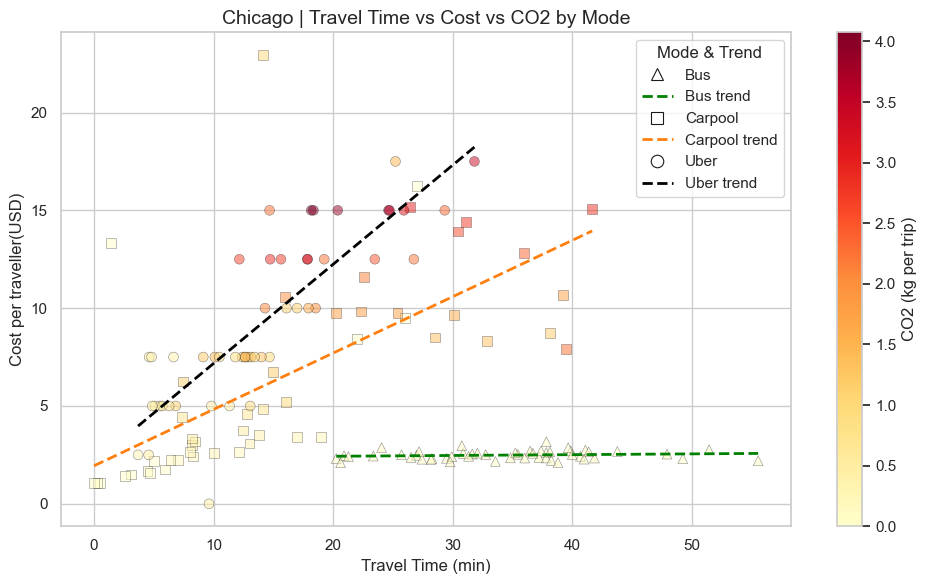

In [51]:
# %% 8. Visualization (after outlier removal)
plt.figure(figsize=(10,6))

# Sample the data: up to 50 random rows per mode for plotting (reproducible)
# If a mode has fewer than 50 rows, take all available rows for that mode
df_plot = (
    df_filtered.groupby('mode', group_keys=False)
    .apply(lambda g: g.sample(n=min(50, len(g)), random_state=42))
    .reset_index(drop=True)
)

# We'll draw each mode separately so we can have distinct markers in a legend
from matplotlib.lines import Line2D

modes = list(df_plot['mode'].unique())
# Define a marker for each mode (add more if you have more modes)
marker_map = {'Uber': 'o', 'Carpool': 's', 'Bus': '^'}

# Use a clear categorical palette for modes and use same palette for trend lines
palette_modes = sns.color_palette('tab10', n_colors=max(1, len(modes)))
mode_color_map = {mode: palette_modes[i] for i, mode in enumerate(modes)}
mode_line_color = mode_color_map
# Force Uber trend line to black and Bus trend line to green for contrast
if 'Uber' in mode_line_color:
    mode_line_color['Uber'] = 'black'
if 'Bus' in mode_line_color:
    mode_line_color['Bus'] = 'green'

# Colormap for CO2: use Matplotlib's sequential 'YlOrRd' (yellow -> orange -> red)
cmap = plt.cm.get_cmap('YlOrRd')

# Colormap normalization for CO2 values (shared across modes)
vmin = df_plot['co2_kg'].min()
vmax = df_plot['co2_kg'].max()
# Avoid zero range in normalization
if vmin == vmax:
    vmax = vmin + 1e-6
norm = plt.Normalize(vmin=vmin, vmax=vmax)

# Keep track of which modes got trend lines (for legend)
mode_trends_drawn = set()

# Plot each mode separately using matplotlib scatter so marker legend is simple to create
for mode in modes:
    subset = df_plot[df_plot['mode'] == mode]
    m = marker_map.get(mode, 'o')
    plt.scatter(
        subset['travel_time_min'],
        subset['cost_usd'],
        c=subset['co2_kg'],
        cmap=cmap,
        norm=norm,
        s=50,
        alpha=0.5,  # increased transparency
        marker=m,
        edgecolor='k',  # thin black border
        linewidths=0.4,
    )

    # Add a simple linear regression line for this mode (if enough distinct x points)
    if len(subset) >= 2 and subset['travel_time_min'].nunique() >= 2:
        try:
            coeffs = np.polyfit(subset['travel_time_min'], subset['cost_usd'], 1)
            x_line = np.linspace(subset['travel_time_min'].min(), subset['travel_time_min'].max(), 100)
            y_line = np.polyval(coeffs, x_line)
            plt.plot(x_line, y_line, color=mode_line_color[mode], linestyle='--', linewidth=2)
            mode_trends_drawn.add(mode)
        except Exception:
            # If fitting fails for any reason, skip this mode's trend line
            pass

# (Overall regression removed by user request)

plt.title("Chicago | Travel Time vs Cost vs CO2 by Mode", fontsize=14)
plt.xlabel("Travel Time (min)")
plt.ylabel("Cost per traveller(USD)")

# Create a continuous colorbar for CO2 using a ScalarMappable tied to the same norm/cmap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
ax = plt.gca()
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("CO2 (kg per trip)")

# Create custom legend handles for modes (markers only) and combine with regression line handles
legend_handles = []
legend_labels = []
for mode in modes:
    marker = marker_map.get(mode, 'o')
    # Marker handle: white face with thin black edge to match plotted markers
    mhandle = Line2D([0], [0], marker=marker, color='w', label=mode, markerfacecolor='white', markersize=9, markeredgecolor='k', markeredgewidth=0.8)
    legend_handles.append(mhandle)
    legend_labels.append(mode)
    # Line handle (if we drew a regression for this mode)
    if mode in mode_trends_drawn:
        lhandle = Line2D([0], [0], color=mode_line_color[mode], lw=2, linestyle='--', label=f"{mode} trend")
        legend_handles.append(lhandle)
        legend_labels.append(f"{mode} trend")

plt.legend(handles=legend_handles, labels=legend_labels, title='Mode & Trend', loc='best')
plt.tight_layout()
plt.show()
